In [1]:
import os
import time
import random
import pickle
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report

# Glavne konstante
DATA_PATH = '/home/aljaz/Desktop/workspace/FERI/magisterij/ROSIS/09_remove_noise/datasets/librispeech/LibriSpeech/dev-clean'
SAMPLE_RATE = 16000     # Standard za LibriSpeech
TARGET_DURATION = 10    # Največja dolžina posnetka v sekundah
SEGMENT_LENGTH = 2      # Dolžina segmenta v sekundah

# Parametri za Mel spektrogram
N_MELS = 128            # Število Mel filtrov
N_FFT = 2048            # Dolžina FFT okna
HOP_LENGTH = 512        # Korak premika okna

In [2]:
# 2. ANALIZA PODATKOVNE ZBIRKE
def analyze_dataset(data_path):
    print("--- 2. Analiza Podatkovne Zbirke ---")
    speaker_stats = defaultdict(lambda: {'count': 0, 'durations': []})
    all_durations = []

    for speaker_id in os.listdir(data_path):
        speaker_path = os.path.join(data_path, speaker_id)
        if not os.path.isdir(speaker_path): continue

        for chapter_id in os.listdir(speaker_path):
            chapter_path = os.path.join(speaker_path, chapter_id)
            if not os.path.isdir(chapter_path): continue

            for file_name in os.listdir(chapter_path):
                if file_name.endswith('.flac'):
                    file_path = os.path.join(chapter_path, file_name)
                    try:
                        duration = librosa.get_duration(path=file_path, sr=SAMPLE_RATE)
                        speaker_stats[speaker_id]['count'] += 1
                        speaker_stats[speaker_id]['durations'].append(duration)
                        all_durations.append(duration)
                    except Exception as e:
                        print(f"Napaka pri obdelavi datoteke {file_path}: {e}")

    num_speakers = len(speaker_stats)
    num_recordings = len(all_durations)
    recordings_per_speaker = [s['count'] for s in speaker_stats.values()]

    print(f"Naslov/Povezava: LibriSpeech ASR corpus (dev-clean subset)")
    print(f"Vzorčevalna frekvenca: {SAMPLE_RATE} Hz")
    print(f"Število govorcev: {num_speakers}")
    print(f"Število vseh posnetkov: {num_recordings}")

    stats_df = pd.DataFrame(recordings_per_speaker)
    print("\nŠtevilo posnetkov na govorca:")
    print(stats_df.describe().transpose())

    duration_df = pd.DataFrame(all_durations)
    print("\nDolžina posnetkov (v sekundah):")
    print(duration_df.describe().transpose())

    # Histogram: Porazdelitev števila posnetkov na govorca
    plt.figure(figsize=(10, 6))
    sns.histplot(recordings_per_speaker, bins=20, kde=True)
    plt.title('Histogram porazdelitve števila posnetkov na govorca')
    plt.xlabel('Število posnetkov')
    plt.ylabel('Število govorcev')
    plt.grid(True)
    plt.show()

    # Histogram: Porazdelitev dolžin posnetkov
    plt.figure(figsize=(10, 6))
    sns.histplot(all_durations, bins=50, kde=True)
    plt.title('Histogram porazdelitve dolžin posnetkov')
    plt.xlabel('Dolžina posnetka (s)')
    plt.ylabel('Število posnetkov')
    plt.grid(True)
    plt.show()

--- 2. Analiza Podatkovne Zbirke ---
Naslov/Povezava: LibriSpeech ASR corpus (dev-clean subset)
Vzorčevalna frekvenca: 16000 Hz
Število govorcev: 40
Število vseh posnetkov: 2703

Število posnetkov na govorca:
   count    mean       std   min   25%   50%   75%    max
0   40.0  67.575  16.71463  36.0  56.5  68.0  78.0  101.0

Dolžina posnetkov (v sekundah):
    count      mean       std    min   25%   50%     75%     max
0  2703.0  7.175775  4.695612  1.445  3.76  5.92  9.2675  32.645


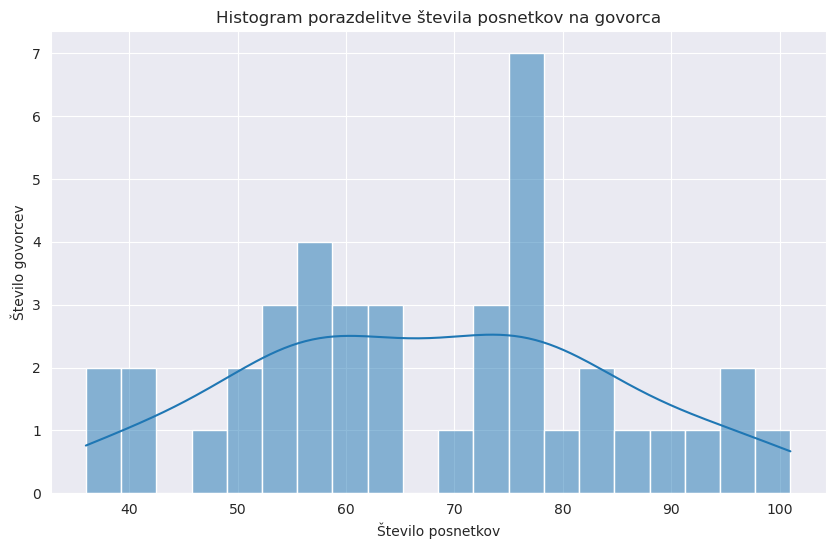

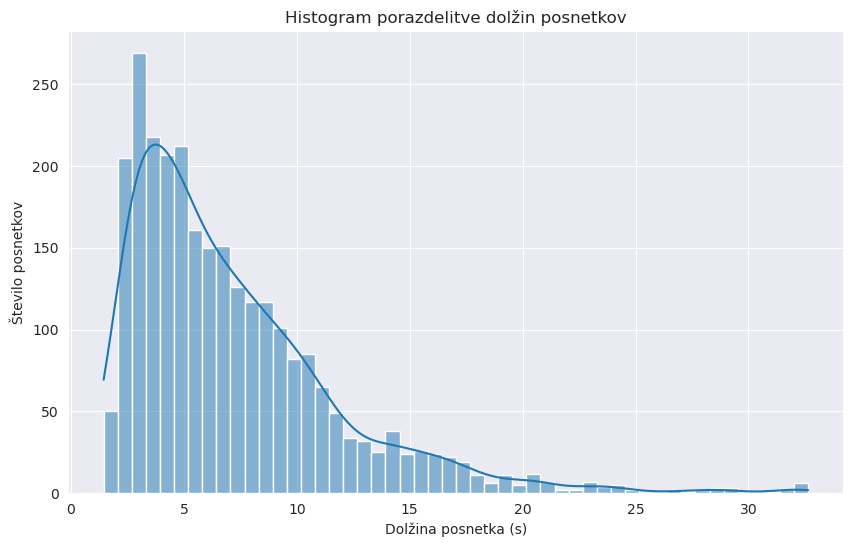

In [3]:
analyze_dataset(DATA_PATH)

In [4]:
# 3. PREDPROCESIRANJE IN ZNAČILKE
def process_and_segment_audio(file_path):
    """
    Naloži avdio, ga obreže na TARGET_DURATION in razreže na SEGMENT_LENGTH kose.
    """
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

        # Obreži na največ 10 sekund
        if len(y) > TARGET_DURATION * sr:
            y = y[:TARGET_DURATION * sr]

        # Razreži na 2-sekundne kose
        segment_samples = int(SEGMENT_LENGTH * sr)
        segments = []
        for start in range(0, len(y), segment_samples):
            end = start + segment_samples
            if end <= len(y):
                segment = y[start:end]
                segments.append(segment)
        return segments
    except Exception as e:
        print(f"Napaka pri segmentaciji datoteke {file_path}: {e}")
        return []

def extract_mel_spectrogram(audio_segment):
    """
    Izračuna log-Mel spektrogram iz avdio segmenta.
    """
    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio_segment, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    return log_mel_spectrogram

def load_and_process_data(data_path):
    """
    Glavna funkcija za nalaganje in procesiranje podatkov.
    """
    print("\n--- 3. Zbiranje in Segmentacija Avdio Podatkov ---")
    speaker_segments = defaultdict(list)
    for speaker_id in sorted(os.listdir(data_path)):
        speaker_path = os.path.join(data_path, speaker_id)
        if not os.path.isdir(speaker_path): continue

        for chapter_id in os.listdir(speaker_path):
            chapter_path = os.path.join(speaker_path, chapter_id)
            if not os.path.isdir(chapter_path): continue

            for file_name in os.listdir(chapter_path):
                if file_name.endswith('.flac'):
                    file_path = os.path.join(chapter_path, file_name)
                    segments = process_and_segment_audio(file_path)
                    speaker_segments[speaker_id].extend(segments)

    total_segments = sum(len(v) for v in speaker_segments.values())
    print(f"Končano. Zbranih {total_segments} segmentov od {len(speaker_segments)} govorcev.")
    return speaker_segments

In [5]:
speaker_segments_dict = load_and_process_data(DATA_PATH)


--- 3. Zbiranje in Segmentacija Avdio Podatkov ---
Končano. Zbranih 7400 segmentov od 40 govorcev.


In [6]:
# 4. RAZDELITEV NA MNOŽICE
def create_splits(speaker_segments):
    """
    Razdeli govorce na učno, validacijsko in testno množico.
    """
    print("\n--- 4. Razdelitev na Učno, Validacijsko in Testno Množico ---")
    all_speaker_ids = list(speaker_segments.keys())
    random.seed(42) # za ponovljivost
    random.shuffle(all_speaker_ids)

    train_split, val_split = 0.8, 0.1
    train_idx_end = int(len(all_speaker_ids) * train_split)
    val_idx_end = train_idx_end + int(len(all_speaker_ids) * val_split)

    train_speaker_ids = all_speaker_ids[:train_idx_end]
    val_speaker_ids = all_speaker_ids[train_idx_end:val_idx_end]
    test_speaker_ids = all_speaker_ids[val_idx_end:]

    def print_split_stats(name, ids, all_segments):
        num_speakers = len(ids)
        num_segments = sum(len(all_segments[spk_id]) for spk_id in ids)
        print(f"  - {name}: {num_speakers} govorcev, {num_segments} segmentov")
        return [len(all_segments[spk_id]) for spk_id in ids]

    print("Velikosti množic:")
    train_counts = print_split_stats("Učna", train_speaker_ids, speaker_segments)
    val_counts = print_split_stats("Validacijska", val_speaker_ids, speaker_segments)
    test_counts = print_split_stats("Testna", test_speaker_ids, speaker_segments)

    # Histogram porazdelitve segmentov v množicah
    plt.figure(figsize=(12, 7))
    sns.histplot(train_counts, color='blue', label='Učna', alpha=0.6, bins=15)
    sns.histplot(val_counts, color='orange', label='Validacijska', alpha=0.8, bins=15)
    sns.histplot(test_counts, color='green', label='Testna', alpha=0.7, bins=15)
    plt.title('Porazdelitev števila segmentov na govorca po množicah')
    plt.xlabel('Število 2s segmentov')
    plt.ylabel('Število govorcev')
    plt.legend()
    plt.grid(True)
    plt.show()

    return train_speaker_ids, val_speaker_ids, test_speaker_ids



--- 4. Razdelitev na Učno, Validacijsko in Testno Množico ---
Velikosti množic:
  - Učna: 32 govorcev, 5976 segmentov
  - Validacijska: 4 govorcev, 718 segmentov
  - Testna: 4 govorcev, 706 segmentov


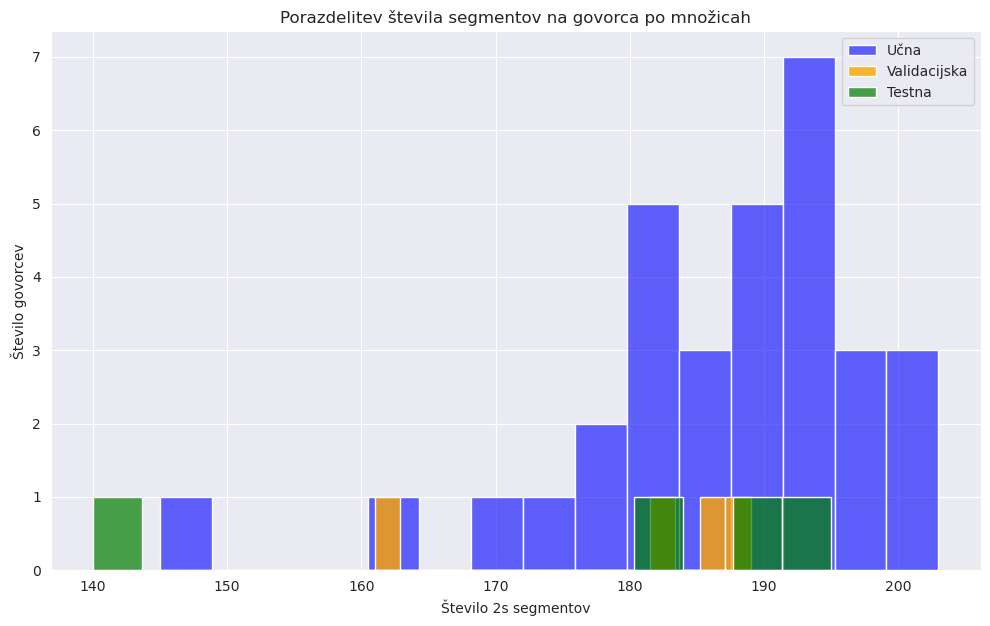

In [7]:
train_ids, val_ids, test_ids = create_splits(speaker_segments_dict)

In [8]:
import os
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/opt/cuda/"

def create_dataset(speaker_ids, all_segments_dict, mapping):
    """
    Ustvari (X, y) pare (spektrogrami, oznake) za podano množico govorcev.
    """
    X, y = [], []
    for speaker_id in speaker_ids:
        label = mapping[speaker_id]
        for segment in all_segments_dict[speaker_id]:
            mel_spec = extract_mel_spectrogram(segment)
            X.append(mel_spec)
            y.append(label)
    # Pretvori v numpy array in preveri obliko
    X = np.array(X)
    if X.ndim == 2: # Primer, ko je vrnjen samo en spektrogram
        X = np.expand_dims(X, axis=0)
    return X, np.array(y)


def prepare_final_datasets(speaker_segments, train_ids, val_ids, test_ids):
    """
    Pripravi končne numpy arraye za učenje, vključno z one-hot kodiranjem.
    """
    print("\n--- 5. Priprava Podatkov za Model ---")
    all_unique_speakers = sorted(speaker_segments.keys())
    speaker_to_int = {speaker: i for i, speaker in enumerate(all_unique_speakers)}
    num_classes = len(all_unique_speakers)

    print("Ustvarjam učno množico...")
    X_train, y_train = create_dataset(train_ids, speaker_segments, speaker_to_int)
    print("Ustvarjam validacijsko množico...")
    X_val, y_val = create_dataset(val_ids, speaker_segments, speaker_to_int)
    print("Ustvarjam testno množico...")
    X_test, y_test = create_dataset(test_ids, speaker_segments, speaker_to_int)

    # Dodaj "kanalno" dimenzijo za CNN
    X_train = np.expand_dims(X_train, -1)
    X_val = np.expand_dims(X_val, -1)
    X_test = np.expand_dims(X_test, -1)

    # One-hot kodiranje oznak
    y_train = to_categorical(y_train, num_classes=num_classes)
    y_val = to_categorical(y_val, num_classes=num_classes)
    y_test = to_categorical(y_test, num_classes=num_classes)

    print(f"Oblika učne množice X: {X_train.shape}, y: {y_train.shape}")
    print(f"Oblika validacijske množice X: {X_val.shape}, y: {y_val.shape}")
    print(f"Oblika testne množice X: {X_test.shape}, y: {y_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), num_classes


2025-07-06 19:05:37.880251: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751821537.894261  203766 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751821537.898860  203766 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:
(X_train, y_train), (X_val, y_val), (X_test, y_test), num_classes = prepare_final_datasets(
    speaker_segments_dict, train_ids, val_ids, test_ids
)


--- 5. Priprava Podatkov za Model ---
Ustvarjam učno množico...
Ustvarjam validacijsko množico...
Ustvarjam testno množico...
Oblika učne množice X: (5976, 128, 63, 1), y: (5976, 40)
Oblika validacijske množice X: (718, 128, 63, 1), y: (718, 40)
Oblika testne množice X: (706, 128, 63, 1), y: (706, 40)


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, GRU, Dense, Dropout,
    Permute, Reshape
)
from tensorflow.keras.regularizers import l2

def build_model(input_shape, num_classes):
    """
    Zgradi poenostavljen in močno regulariziran CRNN model,
    da se prepreči prekomerno učenje.
    """
    print("\n--- Gradnja izboljšanega in poenostavljenega CRNN Modela ---")

    # Uporaba L2 regularizacije za preprečevanje overfittinga
    # Kaznuje velike uteži in spodbuja model k učenju bolj robustnih značilk.
    regularizer = l2(0.001)

    # Calculate the output shape after the CNN blocks to determine the Reshape dimensions
    # We need to simulate the CNN operations to get the correct dimensions
    # Input shape is (height, width, channels) or (time_steps, features, channels)
    # After first MaxPooling2D (pool_size=(2, 2)), height and width are halved
    height_after_cnn = input_shape[0] // (2 * 2) # After two MaxPooling2D layers
    width_after_cnn = input_shape[1] // (2 * 2)  # After two MaxPooling2D layers
    channels_after_cnn = 64 # From the last Conv2D layer

    # The Reshape layer needs to flatten the last two dimensions (width and channels)
    # into one dimension for the GRU. The 'time_steps' dimension remains as is.
    # After Permute((2, 1, 3)), the dimensions become (width_after_cnn, height_after_cnn, channels_after_cnn)
    # So, the new 'features' for GRU will be height_after_cnn * channels_after_cnn
    reshape_dim = height_after_cnn * channels_after_cnn

    model = Sequential([
        Input(shape=input_shape),

        # --- Poenostavljen CNN Blok ---
        # Uporabljamo manj filtrov, da zmanjšamo kompleksnost modela.
        Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=regularizer),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=regularizer),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # --- Priprava za RNN ---
        # Uporabljamo robusten način s Permute in Reshape
        # Original: (batch, height, width, channels)
        # Permute((2, 1, 3)) -> (batch, width, height, channels)
        Permute((2, 1, 3)),
        # Reshape((-1, model.output_shape[2] * model.output_shape[3]))
        # The first dimension (-1) means it's inferred from the input.
        # The second dimension is the flattened features for the GRU.
        Reshape((-1, reshape_dim)),

        # --- Poenostavljena RNN Plast ---
        # Manjše število GRU enot bistveno zmanjša tveganje za overfitting.
        # Dodamo tudi regularizacijo na jedra in rekurzivna jedra.
        GRU(64, return_sequences=False, kernel_regularizer=regularizer, recurrent_regularizer=regularizer),
        Dropout(0.5), # Dropout je ključen za regularizacijo RNN plasti

        # --- Klasifikacijska Plast ---
        # Odstranili smo odvečno Dense plast in dodali regularizacijo
        Dense(num_classes, activation='softmax', kernel_regularizer=regularizer)
    ])

    # Uporabimo nižjo stopnjo učenja za bolj stabilno konvergenco
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [21]:

# Oblika vhoda je (n_mels, n_timesteps, 1)
# n_timesteps = floor(segment_samples / hop_length) + 1
# n_timesteps = floor(16000 * 2 / 512) + 1 = 63
input_shape = X_train.shape[1:]

# Tukaj lahko spreminjate parametre za eksperimente
baseline_model = build_model(
    input_shape=input_shape,
    num_classes=num_classes,
)


--- Gradnja izboljšanega in poenostavljenega CRNN Modela ---


In [22]:
# 7. UČENJE IN VREDNOTENJE
def run_experiment(model, train_data, val_data, test_data, epochs=50, batch_size=32):
    """
    Funkcija, ki izvede učenje, vrednotenje in shrani rezultate.
    """
    print("\n--- 7. Učenje in Vrednotenje ---")

    X_train, y_train = train_data
    X_val, y_val = val_data
    X_test, y_test = test_data

    # Kompilacija modela
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    # Callbacki
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

    # Merjenje časa učenja
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, model_checkpoint]
    )

    end_time = time.time()
    training_time = end_time - start_time
    print(f"\nČas učenja: {training_time:.2f} sekund ({training_time/60:.2f} minut)")

    # Shranjevanje zgodovine učenja
    with open('training_history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    print("Zgodovina učenja shranjena v 'training_history.pkl'")
    print("Najboljši model shranjen v 'best_model.h5'")

    # Vrednotenje na testni množici
    print("\nVrednotenje na testni množici:")
    # Naložimo najboljši model
    best_model = tf.keras.models.load_model('best_model.h5')
    loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    print(f"  - Izguba (Loss): {loss:.4f}")
    print(f"  - Natančnost (Accuracy): {accuracy:.4f}")

    return best_model, history

def plot_history(history):
    """Izriše grafe natančnosti in izgube."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graf natančnosti
    ax1.plot(history.history['accuracy'], label='Natančnost (učna)')
    ax1.plot(history.history['val_accuracy'], label='Natančnost (validacijska)')
    ax1.set_title('Metrika natančnosti skozi epohe')
    ax1.set_xlabel('Epoha')
    ax1.set_ylabel('Natančnost')
    ax1.legend()
    ax1.grid(True)

    # Graf izgube
    ax2.plot(history.history['loss'], label='Izguba (učna)')
    ax2.plot(history.history['val_loss'], label='Izguba (validacijska)')
    ax2.set_title('Metrika izgube skozi epohe')
    ax2.set_xlabel('Epoha')
    ax2.set_ylabel('Izguba')
    ax2.legend()
    ax2.grid(True)

    plt.show()

def plot_confusion_matrix(model, X_test, y_test, num_classes_to_show=15):
    """Izriše matriko napak."""
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(12, 12))
    sns.heatmap(cm[:num_classes_to_show, :num_classes_to_show], annot=True, fmt='d',
                xticklabels=range(num_classes_to_show), yticklabels=range(num_classes_to_show))
    plt.title(f'Matrika napak (prvih {num_classes_to_show} razredov)')
    plt.ylabel('Dejanski razred')
    plt.xlabel('Napovedan razred')
    plt.show()

    print("\nPoročilo o klasifikaciji (celotna testna množica):")
    print(classification_report(y_true, y_pred_classes))




--- 7. Učenje in Vrednotenje ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 63, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 63, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_2 (Permute)             │ (None, 15, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 15, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │       405,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427,688 (1.63 MB)

 Trainable params: 427,496 (1.63 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
184/187 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1997 - loss: 3.5161

187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2030 - loss: 3.5018 - val_accuracy: 0.0000e+00 - val_loss: 5.3978
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7805 - loss: 1.4419 - val_accuracy: 0.0000e+00 - val_loss: 6.5501
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9297 - loss: 0.8561 - val_accuracy: 0.0000e+00 - val_loss: 6.7573
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9675 - loss: 0.6077 - val_accuracy: 0.0000e+00 - val_loss: 6.3502
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9833 - loss: 0.4938 - val_accuracy: 0.0000e+00 - val_loss: 7.0546
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9954 - loss: 0.4112 - val_accuracy: 0.0000e+00 - val_loss: 6.9135
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9951 - loss: 0.3670 - val_accuracy: 0.0000e+00 - val_loss: 6.7564
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9985 -

  - Izguba (Loss): 5.4016
  - Natančnost (Accuracy): 0.0000


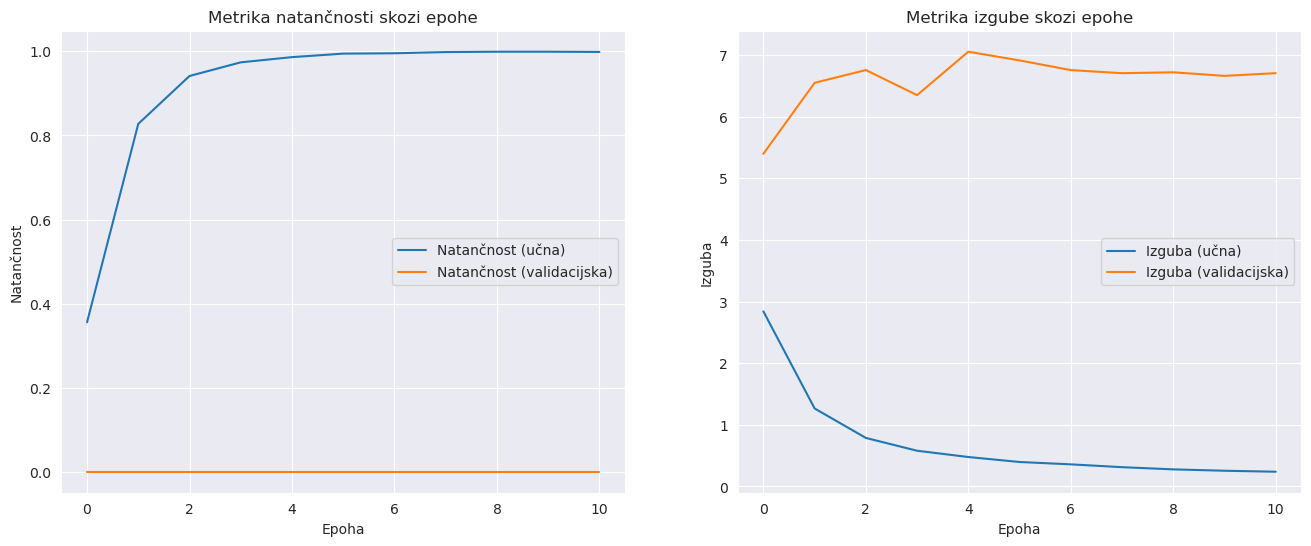

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


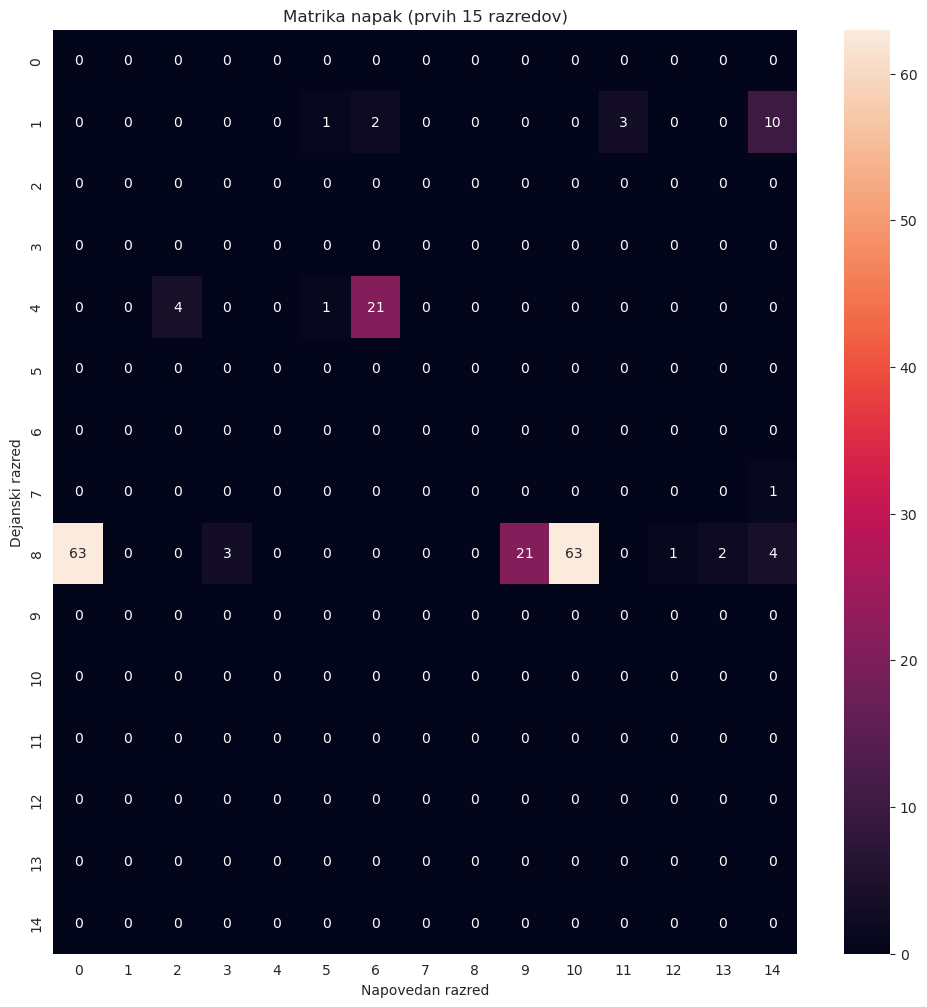


Poročilo o klasifikaciji (celotna testna množica):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00     195.0
           2       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00     182.0
          10       0.00      0.00      0.00       0.0
          11       0.00      0.00      0.00       0.0
          15       0.00      0.00      0.00     140.0
          17       0.00      0.00      0.00     189.0
          19       0.00      0.00      0.00       0.0
          20       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       0.0
          27       0.00      0.00      0.00       0.0
          28       0.00      0.00      0.00       0.0
          29       0.00      0.00      0.00       0.0
          31       0.00      0.00      0.00       0.0
          32       0.00      

/home/aljaz/miniconda3/envs/07_mfcc_in_nm/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/aljaz/miniconda3/envs/07_mfcc_in_nm/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/aljaz/miniconda3/envs/07_mfcc_in_nm/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

In [23]:
trained_model, history_data = run_experiment(
    model=baseline_model,
    train_data=(X_train, y_train),
    val_data=(X_val, y_val),
    test_data=(X_test, y_test),
    epochs=100, # Early stopping bo verjetno prekinil prej
    batch_size=32
)

# Prikaz rezultatov
plot_history(history_data)
plot_confusion_matrix(trained_model, X_test, y_test)